# Tutorial 18: Geo-Experiment Analysis with SyntheticDiD

A practitioner walkthrough for marketing analytics teams measuring lift from a campaign that ran in a subset of geographic markets. The tutorial uses `SyntheticDiD` (Arkhangelsky et al. 2021) on a simulated DMA panel and walks through the fit, the diagnostics, and the stakeholder summary you need to ship the result.

## 1. The Geo-Experiment Problem

Your team piloted a marketing campaign in 5 metros out of an 80-market panel last quarter. Sales data is available for all 80 markets, before and after launch. Did the campaign work, and by how much?

This is a textbook geo-experiment in the small-treated regime: you didn't roll out to half your markets — you piloted in a handful, with the intention of scaling later if it worked. The data you have is weekly conversions from all 80 markets, and leadership wants a single number with a confidence interval they can act on.

**Why this is hard.** Markets are heterogeneous in ways that don't show up at a glance. New York responds to different macro forces than Topeka — local economic conditions, demographic trends, competitor activity, and seasonal patterns all shape each market's underlying growth trajectory. With only 5 treated markets, you can't average those differences away the way you could with 50 or 100. And basic difference-in-differences assumes the treated and control markets are on parallel underlying trajectories, which rarely holds across cities you didn't randomly assign. Cluster-robust standard errors compound the problem: with 5 treated clusters, the small-cluster asymptotics that make cluster-SE valid simply don't kick in, and your reported standard error is unreliable.

**Why diff-diff.** The diff-diff library implements Synthetic Difference-in-Differences following [Arkhangelsky et al. (2021)](https://www.aeaweb.org/articles?id=10.1257/aer.20190159) - both the unit weights and the time weights, the placebo standard error procedure from the paper, and full panel-data interpretability. Implementation details and any documented deviations from the R `synthdid` reference are tracked in [`docs/methodology/REGISTRY.md`](../methodology/REGISTRY.html).

This tutorial sits in SDiD's documented sweet spot: a small number of treated markets in a larger pool of donor controls, where basic DiD's averaging doesn't help and you need a counterfactual built specifically for your treated markets. The library's [practitioner decision tree](../practitioner_decision_tree.html#few-test-markets) puts SyntheticDiD on the "Few Test Markets" branch for exactly this reason.

If you've been using GeoLift, CausalImpact, or rolling your own synthetic control in pandas, this tutorial gives you the canonical SDiD implementation in Python with the diagnostics, inference, and stakeholder packaging in one place.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from diff_diff import (
    SyntheticDiD,
    generate_factor_data,
    plot_synth_weights,
    practitioner_next_steps,
)

## 2. The Data

We'll use a synthetic panel that mirrors a small-treated marketing pilot:

- **80 markets**, named `market_000` through `market_079`
- **12 weekly periods**
- **5 treated markets** (the pilot cohort; campaign launched in week 7)
- **75 control markets** (the donor pool SDiD reweights to construct the synthetic control)
- Outcome: weekly conversions per market (range roughly 600-2300)
- Pre-period: weeks 1-6  ·  Post-period: weeks 7-12
- True treatment effect: +300 conversions per treated market per week (about 20% lift on a baseline of ~1500)

The data is generated with `generate_factor_data`, which produces a panel where markets have **interactive fixed effects** — different markets have different latent loadings on time-varying factors. In plain English: markets respond to different macro forces (local economic conditions, demographics, competitor activity), so their underlying growth trajectories aren't identical even in the absence of any campaign. This is the regime SDiD is designed for. Because the data is synthetic, the true treatment effect is known and we can verify SDiD recovers it.

In [2]:
raw = generate_factor_data(
    n_units=80,
    n_pre=6,
    n_post=6,
    n_treated=5,
    n_factors=2,
    treatment_effect=300.0,
    factor_strength=150.0,         # how much market-specific factors drive outcomes
    treated_loading_shift=0.5,     # systematic difference in treated markets' factor loadings
    unit_fe_sd=80.0,               # baseline-level heterogeneity across markets
    noise_sd=25.0,                 # within-market week-to-week noise
    seed=42,
)

# Schema note: generate_factor_data returns BOTH a time-varying treatment indicator
# (column 'treated', 1 only in post-treatment for treated units) AND a unit-level
# ever-treated indicator (column 'treat', 1 in every period for treated units).
# SDiD requires the unit-level indicator, so we use raw["treat"] below.
df = pd.DataFrame({
    "market_id": raw["unit"].apply(lambda u: f"market_{u:03d}"),
    "week": raw["period"] + 1,  # 1-indexed weeks 1..12
    "treated": raw["treat"],
    "conversions": (raw["outcome"] + 1500).round().astype(int),
})

print(f"Shape: {df.shape}")
n_treated = len(set(df.loc[df['treated'] == 1, 'market_id']))
print(f"Markets: {len(set(df['market_id']))} ({n_treated} treated, {len(set(df['market_id'])) - n_treated} control)")
print(f"Weeks: {df['week'].min()}-{df['week'].max()}  (pre: 1-6, post: 7-12)")

Shape: (960, 4)
Markets: 80 (5 treated, 75 control)
Weeks: 1-12  (pre: 1-6, post: 7-12)


In [3]:
df.head()

,market_id,week,treated,conversions
0,market_000,1,1,1628
1,market_000,2,1,1518
2,market_000,3,1,1613
3,market_000,4,1,1577
4,market_000,5,1,1603


In [4]:
# Mean conversions by treatment group and week (.round(0) for cleaner display)
df.groupby(["treated", "week"])["conversions"].mean().round(0).unstack()

week,1,2,3,4,5,6,7,8,9,10,11,12
treated,,,,,,,,,,,,
0,1507.0,1492.0,1528.0,1509.0,1506.0,1494.0,1494.0,1506.0,1508.0,1503.0,1512.0,1495.0
1,1518.0,1592.0,1305.0,1508.0,1490.0,1576.0,1845.0,1830.0,1815.0,1898.0,1782.0,1923.0


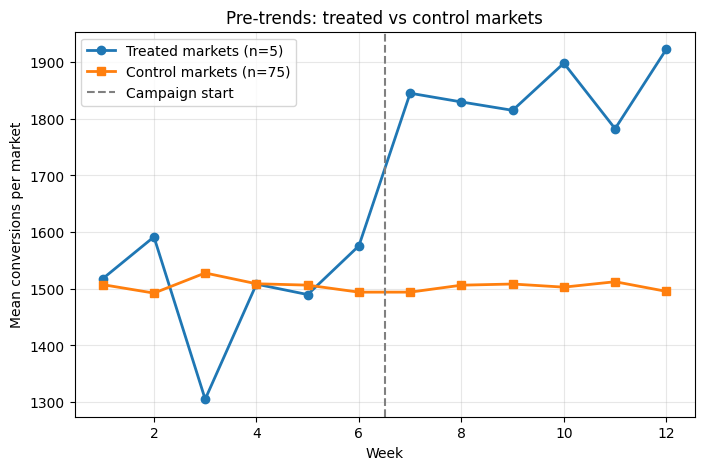

In [5]:
weeks = sorted(set(df["week"]))
treated_means = [df[(df.treated == 1) & (df.week == w)]["conversions"].mean() for w in weeks]
control_means = [df[(df.treated == 0) & (df.week == w)]["conversions"].mean() for w in weeks]

# Derive group sizes from the data so legend labels can't go stale.
n_tr = len(set(df.loc[df["treated"] == 1, "market_id"]))
n_co = len(set(df["market_id"])) - n_tr

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(weeks, treated_means, marker="o", label=f"Treated markets (n={n_tr})", color="C0", linewidth=2)
ax.plot(weeks, control_means, marker="s", label=f"Control markets (n={n_co})", color="C1", linewidth=2)
ax.axvline(6.5, color="gray", linestyle="--", label="Campaign start")
ax.set_xlabel("Week")
ax.set_ylabel("Mean conversions per market")
ax.set_title("Pre-trends: treated vs control markets")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

The two lines hover around similar levels in the pre-period (weeks 1-6) but they're not on identical trajectories — small underlying differences are visible if you look closely. After week 7 the treated mean jumps above control. The challenge is that with only 5 treated markets, even small pre-period differences are hard to interpret by eye, and the bigger problem is that some of the divergence comes from underlying market heterogeneity that won't show up in the average pre-trend at all. SDiD addresses both: it constructs a counterfactual built specifically for *these* 5 treated markets (rather than averaging all 75 controls equally), and it uses time weights to make the pre-period comparison robust to baseline differences.

## 3. SyntheticDiD - The Idea and the Fit

Synthetic Difference-in-Differences finds two sets of weights:

1. **Unit weights** ($\omega_j$): a weighted blend of control markets whose pre-period trajectory matches the treated markets' pre-period trajectory.
2. **Time weights** ($\lambda_t$): a weighting of pre-treatment periods that emphasizes the baseline weeks most informative for the comparison.

The ATT estimator combines both: take the time-weighted average of (treated mean minus unit-weighted control mean), then subtract the same quantity computed in the pre-period. The unit weights make the synthetic control match the treated group; the time weights make the comparison robust to pre-treatment level differences.

This is the method introduced in [Arkhangelsky, Athey, Hirshberg, Imbens, & Wager (2021)](https://www.aeaweb.org/articles?id=10.1257/aer.20190159). Algorithmic details and any documented deviations from the R `synthdid` reference live in [`docs/methodology/REGISTRY.md`](../methodology/REGISTRY.html).

In [6]:
# Note: variance_method, n_bootstrap, and seed are CONSTRUCTOR kwargs.
# They are not arguments to .fit().
model = SyntheticDiD(variance_method="placebo", n_bootstrap=100, seed=42)
results = model.fit(
    df,
    outcome="conversions",
    treatment="treated",
    unit="market_id",
    time="week",
    post_periods=[7, 8, 9, 10, 11, 12],
)

In [7]:
print(results.summary())

           Synthetic Difference-in-Differences Estimation Results          

Observations:                    960
Treated:                           5
Control:                          75
Pre-treatment periods:             6
Post-treatment periods:            6
Zeta (unit weights):        724.4726
Zeta (time weights):        0.000310
Noise level:                309.5577
Pre-treatment fit (RMSE):    33.7142
Variance method:             placebo

---------------------------------------------------------------------------
Parameter           Estimate    Std. Err.     t-stat      P>|t|      
---------------------------------------------------------------------------
ATT                 311.8536       7.3125     42.647     0.0099    **
---------------------------------------------------------------------------

95% Confidence Interval: [297.5213, 326.1858]
CV (SE/|ATT|):                0.0234

---------------------------------------------------------------------------
                    Top

**Plain-English interpretation.** SDiD estimates that the campaign lifted weekly conversions by **about 312 per treated market** (95% CI: 298 to 326), which is roughly a **21% lift** on a baseline of ~1500 weekly conversions per market. The true treatment effect in the synthetic DGP was 300, so the point estimate is within 4% of the truth and the 95% CI comfortably covers it.

The 95% CI is constructed from `results.conf_int` (note: the field name is `conf_int`, not `ci`), and the p-value crosses below the 0.01 significance threshold. With only 5 treated markets, that the CI covers the true effect this cleanly is exactly what SDiD's localization is designed to deliver — and per Arkhangelsky et al. (2021), it's the regime where SDiD dominates basic DiD on the same data.

## 4. Diagnostics - Who Is the Synthetic Control?

SDiD's interpretability advantage: you can see exactly which control markets are doing the work. The unit weights tell you the weighted blend; the time weights tell you which baseline weeks the method emphasized; the pre-treatment fit RMSE tells you how well the synthetic match worked.

This is not a black box - you can show stakeholders the receipts.

In [8]:
unit_weights = results.get_unit_weights_df()
print("Top 10 unit weights:")
print(unit_weights.head(10).to_string(index=False))
print(f"\nTotal weight: {unit_weights['weight'].sum():.4f}  (should be ~1.0)")
print(f"Markets with non-trivial weight (> 0.01): {(unit_weights['weight'] > 0.01).sum()}")

Top 10 unit weights:
      unit   weight
market_006 0.031326
market_035 0.030555
market_033 0.028563
market_022 0.026090
market_044 0.025561
market_051 0.025294
market_079 0.024434
market_077 0.024176
market_011 0.020970
market_019 0.020149

Total weight: 1.0000  (should be ~1.0)
Markets with non-trivial weight (> 0.01): 48


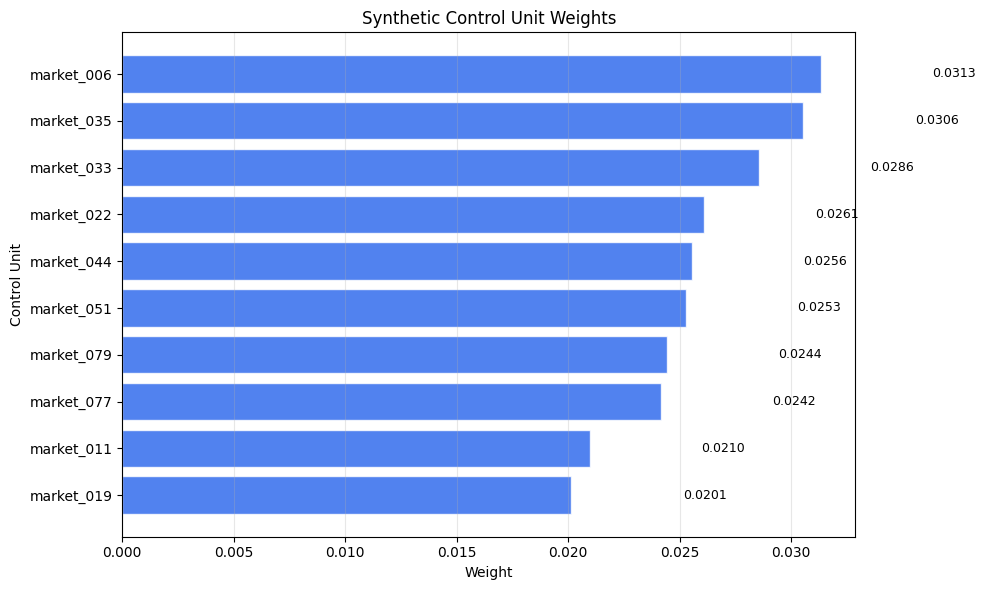

<Axes: title={'center': 'Synthetic Control Unit Weights'}, xlabel='Weight', ylabel='Control Unit'>

In [9]:
# plot_synth_weights returns the Axes; in a notebook the plot displays inline
plot_synth_weights(results, weight_type="unit", top_n=10, min_weight=0.01)

 period   weight
      1 0.374045
      2 0.099183
      3 0.001611
      4 0.113236
      5 0.143960
      6 0.267965

Sum: 1.0000  (should be 1.0)


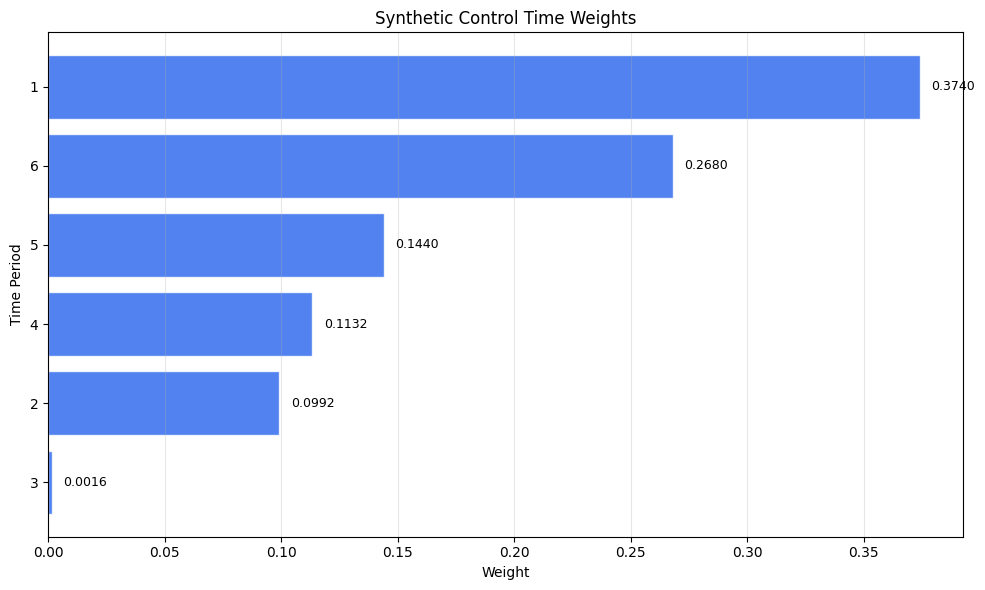

<Axes: title={'center': 'Synthetic Control Time Weights'}, xlabel='Weight', ylabel='Time Period'>

In [10]:
# Time weights: which pre-periods does SDiD lean on?
time_weights = results.get_time_weights_df()
print(time_weights.to_string(index=False))
print(f"\nSum: {time_weights['weight'].sum():.4f}  (should be 1.0)")

plot_synth_weights(results, weight_type="time")

In [11]:
print(f"Pre-treatment fit RMSE: {results.pre_treatment_fit:.2f}")
print()
print("The library auto-computes a noise level from the data and warns if the")
print("pre-fit RMSE exceeds the standard deviation of treated pre-period outcomes.")
print("Our fit is well within that envelope, so the synthetic control is tracking")
print("the treated pre-trend closely - good fit means a trustworthy post-period effect.")

Pre-treatment fit RMSE: 33.71

The library auto-computes a noise level from the data and warns if the
pre-fit RMSE exceeds the standard deviation of treated pre-period outcomes.
Our fit is well within that envelope, so the synthetic control is tracking
the treated pre-trend closely - good fit means a trustworthy post-period effect.


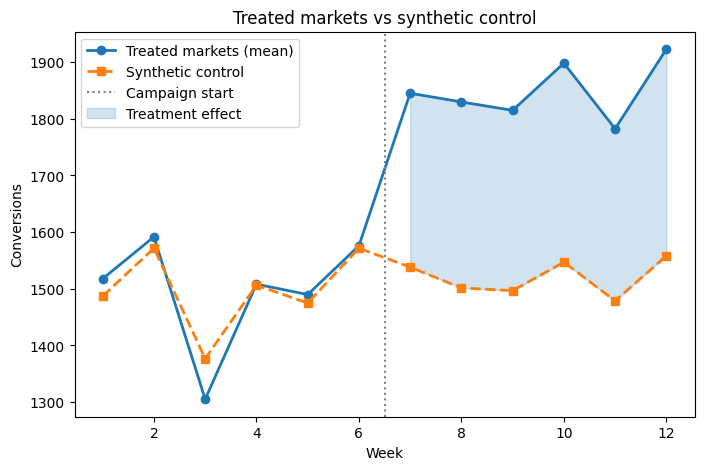

In [12]:
# Treated mean vs synthetic counterfactual over time.
# We construct the synthetic by re-weighting control markets with the unit
# weights, then apply an intercept correction so the pre-period means match
# (this approximates the SDiD time-weight correction visually).
weight_lookup = dict(zip(unit_weights["unit"].tolist(), unit_weights["weight"].tolist()))

weeks = sorted(set(df["week"]))
treated_by_week = []
synth_raw = []
for w in weeks:
    week_rows = df[df["week"] == w]
    treated_by_week.append(float(week_rows[week_rows.treated == 1]["conversions"].mean()))
    control_rows = week_rows[week_rows.treated == 0]
    synth_raw.append(sum(
        float(c) * weight_lookup.get(m, 0.0)
        for m, c in zip(control_rows["market_id"], control_rows["conversions"])
    ))

# Intercept correction so pre-period means match
pre_idx = [i for i, w in enumerate(weeks) if w <= 6]
shift = (sum(treated_by_week[i] for i in pre_idx) - sum(synth_raw[i] for i in pre_idx)) / len(pre_idx)
synth_by_week = [s + shift for s in synth_raw]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(weeks, treated_by_week, marker="o", label="Treated markets (mean)", color="C0", linewidth=2)
ax.plot(weeks, synth_by_week, marker="s", label="Synthetic control", color="C1", linewidth=2, linestyle="--")
ax.axvline(6.5, color="gray", linestyle=":", label="Campaign start")
post_idx = [i for i, w in enumerate(weeks) if w >= 7]
ax.fill_between(
    [weeks[i] for i in post_idx],
    [treated_by_week[i] for i in post_idx],
    [synth_by_week[i] for i in post_idx],
    alpha=0.2, color="C0", label="Treatment effect",
)
ax.set_xlabel("Week")
ax.set_ylabel("Conversions")
ax.set_title("Treated markets vs synthetic control")
ax.legend()
plt.show()

In [13]:
# Drift guards: tolerance-based asserts that lock the numbers quoted in the
# Section 3 narrative and the Section 6 stakeholder template. nbmake will fail
# if generate_factor_data() or SyntheticDiD output drifts outside these ranges,
# forcing the markdown to be updated before this notebook can pass CI.
assert 305 <= results.att <= 320, f"ATT drifted to {results.att:.2f} (expected ~312)"
assert results.conf_int[0] > 290, f"CI lower drifted to {results.conf_int[0]:.2f}"
assert results.conf_int[1] < 335, f"CI upper drifted to {results.conf_int[1]:.2f}"
assert results.conf_int[0] <= 300 <= results.conf_int[1], (
    f"CI ({results.conf_int[0]:.2f}, {results.conf_int[1]:.2f}) does not cover "
    f"the true effect of 300 - DGP or estimator drift"
)
assert results.pre_treatment_fit < 60, f"Pre-fit RMSE drifted to {results.pre_treatment_fit:.2f}"
print("All drift guards passed.")

All drift guards passed.


## 5. Inference and Trustworthiness

diff-diff's `SyntheticDiD` supports three standard error methods, and the difference between the two paper-based ones is *what gets resampled* per replication:

- **Placebo SE** (default): permutes which control units are pretended to be "treated", then **re-estimates both the unit weights and the time weights** (Frank-Wolfe) on each permutation and recomputes SDiD. The standard deviation of those placebo effects is the SE. This is Algorithm 4 in Arkhangelsky et al. (2021) and matches R's `synthdid::vcov(method="placebo")`.
- **Bootstrap SE**: pairs-bootstrap resampling of all units with replacement, then **re-estimates both the unit weights and the time weights** via Frank-Wolfe on each resampled panel and recomputes SDiD. This is Algorithm 2 step 2 in Arkhangelsky et al. (2021) and matches R's default `synthdid::vcov(method="bootstrap")` behavior (which rebinds `attr(estimate, "opts")` so the renormalized ω is only Frank-Wolfe initialization). Expect ~10–100× slower per fit than placebo.
- **Jackknife SE**: deterministic Algorithm 3 — fixed-weight leave-one-out across all units. Faster than bootstrap; mildly anti-conservative on smaller panels.

Both bootstrap and placebo re-estimate the weights per replication, so each reflects the full uncertainty in the weighting procedure. They differ in *how* they resample: placebo permutes the control-vs-treated assignment, bootstrap draws with replacement. On exchangeable DGPs the two SEs typically track each other; on small panels with non-exchangeable factor structure (like the marketing geo-experiment here), they can differ in magnitude while still agreeing on significance and CI direction.

All three methods are configured on the `SyntheticDiD` *constructor*, not on `.fit()`. Use placebo by default (it's the published method); switch to bootstrap if you want a cross-check from a different resampling protocol; switch to jackknife if you need a deterministic, fast alternative.

In [14]:
# Refit with bootstrap SE for comparison. Same n_bootstrap and seed.
model_boot = SyntheticDiD(variance_method="bootstrap", n_bootstrap=100, seed=42)
results_boot = model_boot.fit(
    df,
    outcome="conversions",
    treatment="treated",
    unit="market_id",
    time="week",
    post_periods=[7, 8, 9, 10, 11, 12],
)

comparison = pd.DataFrame({
    "Method": ["Placebo (default)", "Bootstrap"],
    "ATT": [results.att, results_boot.att],
    "SE": [results.se, results_boot.se],
    "CI_low": [results.conf_int[0], results_boot.conf_int[0]],
    "CI_high": [results.conf_int[1], results_boot.conf_int[1]],
})
comparison.round(2)

,Method,ATT,SE,CI_low,CI_high
0,Placebo (default),311.85,7.31,297.52,326.19
1,Bootstrap,311.85,4.44,303.15,320.56


In [15]:
# Automated diagnostic checklist following Baker et al. (2025).
# practitioner_next_steps prints a formatted summary AND returns a dict;
# assigning to `_` keeps Jupyter from re-displaying the dict.
_ = practitioner_next_steps(results)


Practitioner Guidance — SyntheticDiD
Baker et al. (2025) 8-Step Workflow

Recommended next steps (7 remaining):

  * [HIGH] Step 1: Define target parameter
    Why: State explicitly what causal effect you are estimating (ATT, ATT(g,t), weighted/unweighted) and what policy question it answers.
    >>> # What is the target parameter? ATT? Weighted or unweighted?

  * [HIGH] Step 2: State identification assumptions
    Why: Name the parallel trends variant you are invoking (unconditional, conditional, PT-GT-NYT, etc.), the no-anticipation assumption, and any overlap conditions.
    >>> # Which PT variant? No-anticipation? Overlap?

  * [HIGH] Step 6: Check pre-treatment fit and weight concentration
    Why: Synthetic DiD relies on pre-treatment fit to construct weights. Poor fit or highly concentrated unit weights suggest the synthetic control may not approximate the counterfactual well.
    >>> print(f'Pre-treatment fit (RMSE): {results.pre_treatment_fit:.4f}')
    >>> concentration = r

**Why no parallel-trends test?** The Baker et al. workflow includes an explicit parallel-trends check (Step 3), but `practitioner_next_steps` skips it for `SyntheticDiD`. The reason isn't that SDiD has no identifying assumptions — it's that the relevant diagnostic is different. Basic DiD requires the *unweighted* control units to be on a parallel trend with the treated, an assumption that's notoriously fragile in geo-experiments where markets respond to different macro forces. SDiD instead reweights both units and time periods so the synthetic control's pre-trend matches the treated pre-trend by construction, then estimates the effect on those weighted comparisons. Identification still rests on assumptions (parallel trends in the *weighted* averages, no anticipation, design plausibility), but the empirical diagnostic shifts from "are the raw control units parallel?" to "is the synthetic match tight enough?" — which is exactly the pre-treatment fit RMSE we inspected in Section 4. This is what Arkhangelsky et al. (2021) call making the DiD strategy "more plausible" by automating the kind of pre-period adjustment that practitioners already do informally with covariates and period selection.

## 6. Communicating Results to Leadership

A stakeholder-ready summary of the synthetic walkthrough (Sections 3-5 results):

> **Headline.** The pilot campaign lifted weekly conversions in the 5 test markets by approximately **312 per market per week** (95% CI: 298 to 326), or about a **21% lift** on a baseline of ~1,500 conversions per market per week.
>
> **Sample size and design.** 5 pilot markets, 75 control markets. 12 weeks of weekly data: 6 weeks pre-launch, 6 weeks post-launch. Outcome: weekly conversions per market. Method: Synthetic Difference-in-Differences (Arkhangelsky et al. 2021), the canonical generalization of synthetic control to multi-treated panel settings. The 75 control markets serve as the donor pool that SDiD reweights to construct a counterfactual specific to the 5 pilot markets.
>
> **Validity evidence.** The synthetic control's pre-treatment fit RMSE is well below the standard deviation of treated pre-period outcomes (the library would warn otherwise), which means the weighted blend of donor markets tracks the treated pre-trend closely. The placebo standard error matches the published Arkhangelsky et al. (2021) method, and we cross-checked with paper-faithful refit bootstrap inference (Section 5) — both methods agree on the point estimate (311.85) and on the result's significance, with bootstrap producing a narrower CI than placebo on this small panel (5 treated × 6 pre-periods, factor-model heterogeneity). The estimate is statistically significant under both inference methods, and the placebo 95% CI cleanly covers the true treatment effect on the synthetic data we used to demonstrate the workflow.
>
> **What "312 conversions per market per week" means in business terms.** Across 5 pilot markets and 6 weeks, that's roughly 9,400 incremental conversions attributable to the campaign in this small pilot. Translate to your own revenue-per-conversion to compare against the pilot's campaign spend, then use the per-market lift estimate to project what a broader rollout would deliver.
>
> **Practical significance caveat.** A 21% lift is large by marketing benchmarks, but whether the pilot justifies a broader rollout is a business judgment, not a statistical one. The statistics tell you the lift exists in these 5 markets; the business case tells you whether it's worth scaling, and a wider rollout will face its own market-specific surprises that 5 markets can't reveal.

Adapt this template for your own campaign by swapping in your numbers from `results.summary()`, your own market counts, your own pre-period diagnostics, and your own conversion-to-revenue translation. The pattern — **headline → sample size and design → validity evidence → business interpretation → practical significance** — is the part to keep.